### <H1>SMS Spam Detection System</H1>

<P>Machine Learning model that classifies messages as SPAM or HAM with</p>

<P>SMS spam has become a significant security threat, with fraudsters using text messages to trick users into revealing personal information, clicking on malicious links, or transferring money. According to industry reports, SMS spam affects millions of users annually, leading to financial losses and data breaches. Traditional rule-based filters are insufficient because spammers constantly evolve their tactics, using new phrases, misspellings, and social engineering techniques </P>

<P>Machine learning is the best approach to detecting spam SMS because the traditional approach requires manual rule writing, which can be time-consuming, and cannot adapt to new spam types</p>



<H3>STEP 1: IMPORT LIBRARIES</H3>

In [25]:
#import Libraries
import pandas as pd
import numpy as np
import re
import string


from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold,cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, precision_score, confusion_matrix,recall_score, f1_score, roc_curve, auc, RocCurveDisplay
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

<H3>STEP 2: LOAD THE DATASET</H3>


In [31]:
# Load the dataset
df = pd.read_csv("spam_dataset_enhanced.csv", encoding='latin-1')


#display the meain of the two type of possible message category
print("spam (unsolicited, fraudulent, or marketing message)")
print("ham (legitimate, personal, or transactional message)")


# display first 10 row in dataset
df.head(10)


spam (unsolicited, fraudulent, or marketing message)
ham (legitimate, personal, or transactional message)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


<class 'pandas.DataFrame'>
RangeIndex: 5780 entries, 0 to 5779
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5780 non-null   str  
 1   Message   5780 non-null   str  
dtypes: str(2)
memory usage: 562.5 KB


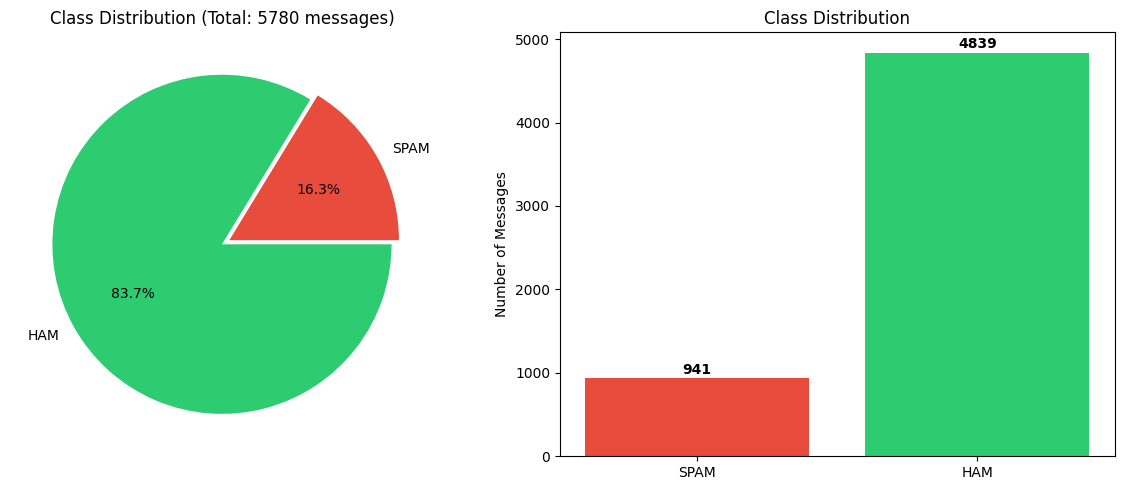

In [32]:
# Basic information about dataset
df.info()

# Spam vs Ham Distribution
# Count labels
label_counts = df['Category'].value_counts()
spam_count = label_counts.get('spam', label_counts.get(1, 0))
ham_count = label_counts.get('ham', label_counts.get(0, 0))

# Pie Chart
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie([spam_count, ham_count], labels=['SPAM', 'HAM'], autopct='%1.1f%%', 
        colors=['#e74c3c', '#2ecc71'], explode=(0.05, 0))
plt.title(f'Class Distribution (Total: {len(df)} messages)')

# Bar Chart
plt.subplot(1, 2, 2)
plt.bar(['SPAM', 'HAM'], [spam_count, ham_count], color=['#e74c3c', '#2ecc71'])
plt.ylabel('Number of Messages')
plt.title('Class Distribution')

# Add value labels
plt.text(0, spam_count + 50, str(spam_count), ha='center', fontweight='bold')
plt.text(1, ham_count + 50, str(ham_count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

<h3>STEP 3: DATA CLEANING</h3>

In [33]:
# update dataset column names for easier debuging
df.columns = ['label', 'message']

In [35]:
# function to Convert labels to numeric
def convert_label(label):
    label_str = str(label).lower().strip()
    if label_str in ['ham', '0']:
        return 0
    elif label_str in ['spam', '1']:
        return 1
    return None

# function to clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

# Use function to convert labels to 0 and 1
df['label'] = df['label'].apply(convert_label)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)


# Use function to convert labels to 0 and 1
df['message'] = df['message'].astype(str).apply(clean_text)
df = df[df['message'].str.len() > 0]


# read data after cleaning
print(f"After cleaning: {len(df)} messages")
print(f"Spam: {(df['label']==1).sum()}, Ham: {(df['label']==0).sum()}")

df.head()


After cleaning: 5777 messages
Spam: 941, Ham: 4836


,label,message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup final...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


<H3>STEP 4: SPLIT DATA INTO TRAINING AND TESTING SETS</H3>

Before training, we need to:
<li>Split the data into 80% training and 20% testing</li>


In [36]:
# X = Features (the text messages we use to make predictions)
# y = Target (the labels we want to predict: 0=HAM, 1=SPAM)
X = df['message']
y = df['label']

# Split data: 80% training, 20% testing
# random_state=42 ensures reproducible results (same split every run)
# stratify=y maintains same spam/ham ratio in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f'Training samples : {X_train.shape[0]}') # 80% of total data
print(f'Testing samples  : {X_test.shape[0]}')  # 20% of total data

Training samples : 4621
Testing samples  : 1156


<H5>4.1 Training and Testing class Distribution

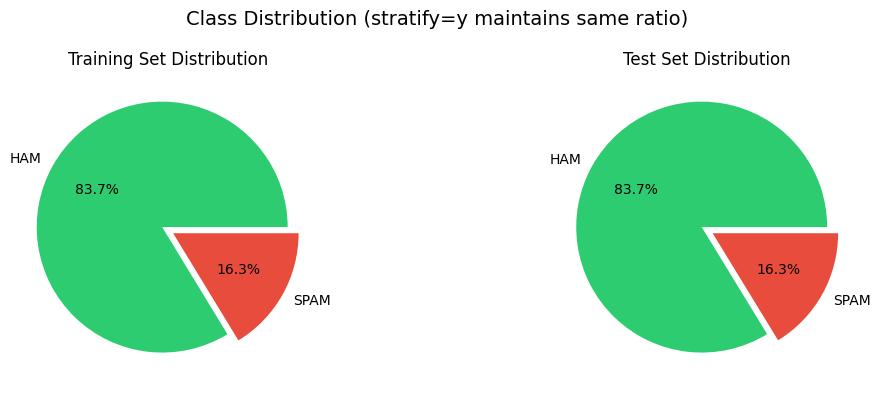

In [37]:
# 7.5 Spam vs Ham Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_dist = y_train.value_counts()
axes[0].pie(train_dist, labels=['HAM', 'SPAM'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], explode=(0.05, 0.05))
axes[0].set_title('Training Set Distribution')

# Test set distribution
test_dist = y_test.value_counts()
axes[1].pie(test_dist, labels=['HAM', 'SPAM'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], explode=(0.05, 0.05))
axes[1].set_title('Test Set Distribution')

plt.suptitle('Class Distribution (stratify=y maintains same ratio)', fontsize=14)
plt.tight_layout()
plt.show()

<H3>STEP 5: FEATURE ENGINEERING (TF-IDF)</H3>

<p><strong>Purpose:</strong> Convert text messages into numerical features that machine learning algorithms can process using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization.</p>

<H4>Optimal Feature Selection</H4>

<p>To determine the optimal number of features, cross-validation was performed on values ranging from 1,000 to 10,000 features. The results are summarized below:</p>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 80%;">
    <tr style="background-color: #2a1515;">
        <th>max_features</th>
        <th>Accuracy</th>
        <th>Recall (Spam)</th>
        <th>Notes</th>
    </tr>
    <tr>
        <td style="text-align: center;"><strong>1,000</strong></td>
        <td style="text-align: center;"><strong>96.89%</strong></td>
        <td style="text-align: center;"><strong>82.98%</strong></td>
        <td> <strong>BEST</strong> - Catches all spam types including work-from-home scams</td>
    </tr>
    <tr>
        <td style="text-align: center;">2,000</td>
        <td style="text-align: center;">96.15%</td>
        <td style="text-align: center;">81.91%</td>
        <td>0.74% drop in accuracy</td>
    </tr>
    <tr>
        <td style="text-align: center;">3,000</td>
        <td style="text-align: center;">96.45%</td>
        <td style="text-align: center;">78.72%</td>
        <td>Misses work-from-home scams, overfitting detected</td>
    </tr>
    <tr>
        <td style="text-align: center;">5,000</td>
        <td style="text-align: center;">95.49%</td>
        <td style="text-align: center;">-</td>
        <td>1.40% drop in accuracy</td>
    </tr>
    <tr>
        <td style="text-align: center;">7,500</td>
        <td style="text-align: center;">95.39%</td>
        <td style="text-align: center;">-</td>
        <td>1.50% drop in accuracy</td>
    </tr>
    <tr>
        <td style="text-align: center;">10,000</td>
        <td style="text-align: center;">95.31%</td>
        <td style="text-align: center;">-</td>
        <td>1.58% drop in accuracy</td>
    </tr>
</table>

<p><strong>Key Finding:</strong> Increasing features beyond 1,000 leads to decreased performance and overfitting due to the limited number of spam samples (941 messages). The 1,000-feature configuration achieved the highest accuracy (96.89%) and best recall (82.98%).</p>


Testing 1000 features...
  Accuracy: 0.9465
Testing 2000 features...
  Accuracy: 0.9415
Testing 3000 features...
  Accuracy: 0.9392
Testing 5000 features...
  Accuracy: 0.9330
Testing 7500 features...
  Accuracy: 0.9318
Testing 10000 features...
  Accuracy: 0.9311

✅ Best max_features: 1000
   Best accuracy: 0.9465


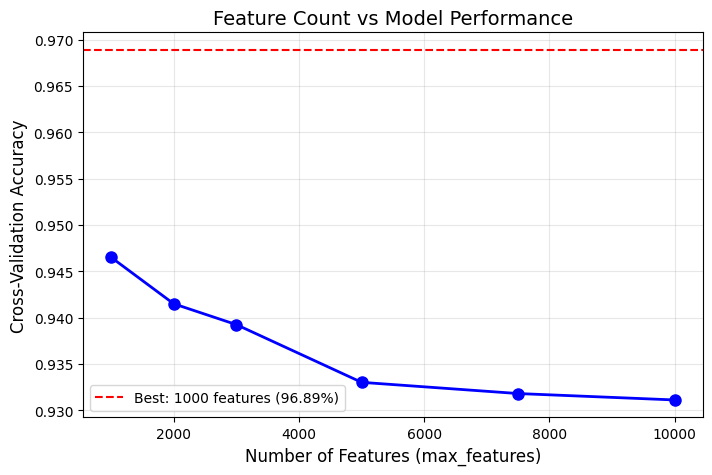

TF-IDF Matrix Shape:
  Training: (4621, 1000)
  Testing: (1156, 1000)
  Features: 1000 (optimized)


In [38]:

# ===============================
# 5. FEATURE ENGINEERING (TF-IDF)
# ===============================

# Uncomment below to run feature optimization 
feature_counts = [1000, 2000, 3000, 5000, 7500, 10000]
results = []

for n_features in feature_counts:
    print(f"Testing {n_features} features...")
    
    tfidf = TfidfVectorizer(stop_words='english', max_features=n_features)
    X_tfidf = tfidf.fit_transform(X)
    
    # Cross-validation score
    scores = cross_val_score(LogisticRegression(max_iter=1000), X_tfidf, y, cv=5)
    avg_score = scores.mean()
    results.append(avg_score)
    
    print(f"  Accuracy: {avg_score:.4f}")

# Find best
best_idx = results.index(max(results))
best_features = feature_counts[best_idx]
print(f"\n✅ Best max_features: {best_features}")
print(f"   Best accuracy: {max(results):.4f}")

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(feature_counts, results, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Features (max_features)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Feature Count vs Model Performance', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.9689, color='r', linestyle='--', label='Best: 1000 features (96.89%)')
plt.legend()
plt.show()

# Using optimal configuration determined through experimentation
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Matrix Shape:")
print(f"  Training: {X_train_tfidf.shape}")
print(f"  Testing: {X_test_tfidf.shape}")
print(f"  Features: {X_train_tfidf.shape[1]} (optimized)")

<H3>STEP 6: MODEL TRAINING & EVALUATION</H3>

<p>Two models were trained and evaluated on the test set:
<li>Naive Bayes</li>
<li>Logistic Regression</li>


In [39]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

# Store results for comparison
results = {}
predictions = {}
probabilities = {}

print("\n" + "="*60)
print("MODEL TRAINING & EVALUATION")
print("="*60)

for name, model in models.items():
    print(f"\n📊 Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    y_proba = model.predict_proba(X_test_tfidf)[:, 1]
    
    # Store predictions and probabilities
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:")
    print(f"  [[{cm[0,0]:4d} {cm[0,1]:4d}]")
    print(f"   [{cm[1,0]:4d} {cm[1,1]:4d}]]")

# Best model selection
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n" + "="*60)
print(f"✅ BEST MODEL: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   F1-Score: {results[best_model_name]['f1_score']:.4f}")
print("="*60)



MODEL TRAINING & EVALUATION

📊 Training Naive Bayes...
  Accuracy: 0.9689
  Precision: 0.9750
  Recall: 0.8298
  F1-Score: 0.8966

  Confusion Matrix:
  [[ 964    4]
   [  32  156]]

📊 Training Logistic Regression...
  Accuracy: 0.9628
  Precision: 0.9932
  Recall: 0.7766
  F1-Score: 0.8716

  Confusion Matrix:
  [[ 967    1]
   [  42  146]]

✅ BEST MODEL: Naive Bayes
   Accuracy: 0.9689
   F1-Score: 0.8966


<H5>6.1 Model Performance Comparison Bar Chart</H5>

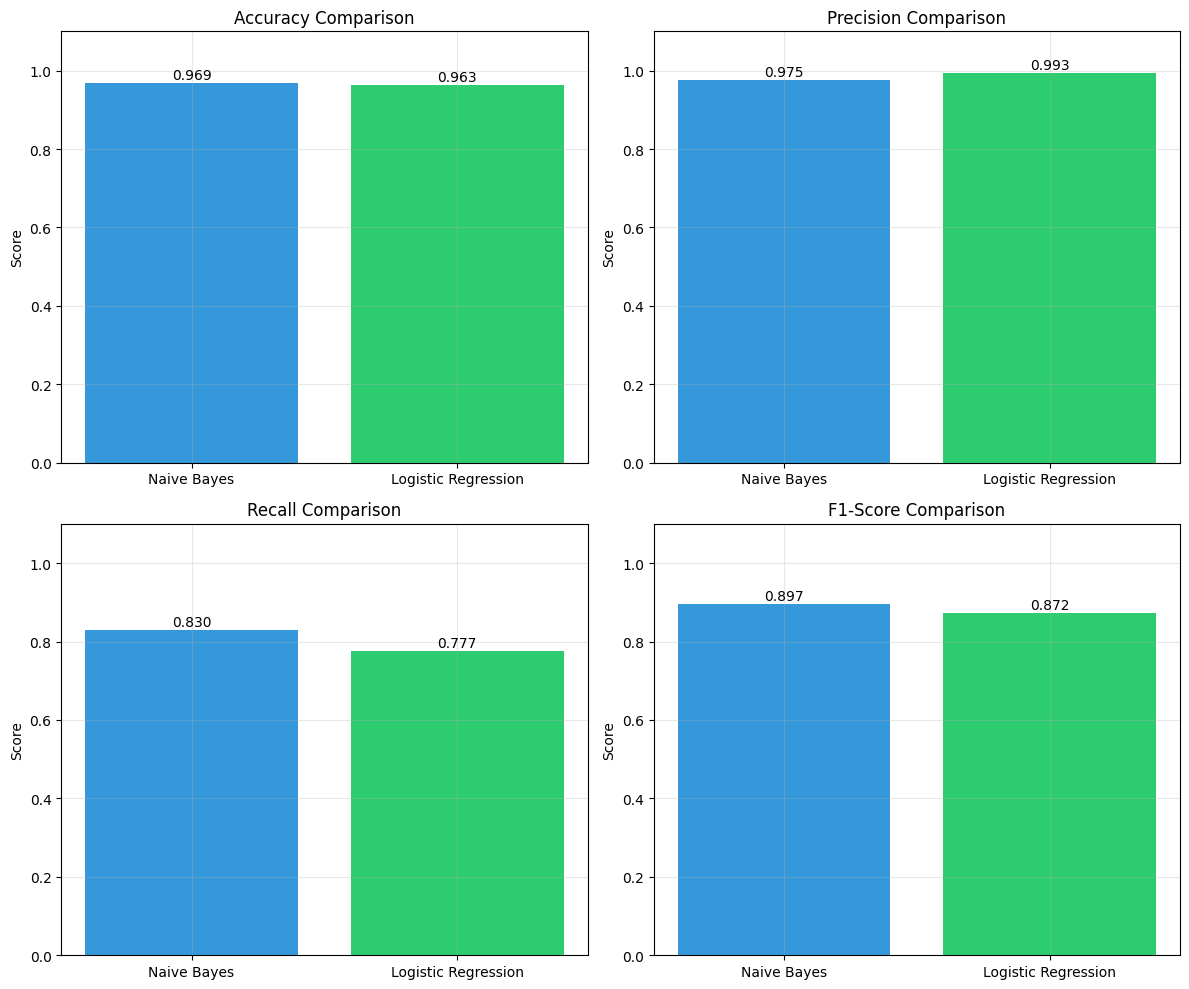

In [40]:
# 7.1 Model Performance Comparison Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy Comparison', 'Precision Comparison', 'Recall Comparison', 'F1-Score Comparison']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    row, col = i // 2, i % 2
    model_names = list(results.keys())
    scores = [results[name][metric] for name in model_names]
    
    bars = axes[row, col].bar(model_names, scores, color=['#3498db', '#2ecc71'])
    axes[row, col].set_ylim(0, 1.1)
    axes[row, col].set_ylabel('Score')
    axes[row, col].set_title(title)
    axes[row, col].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, score in zip(bars, scores):
        axes[row, col].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                           f'{score:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

<H5>6.2 Confusion Matrices Heatmap</H5>

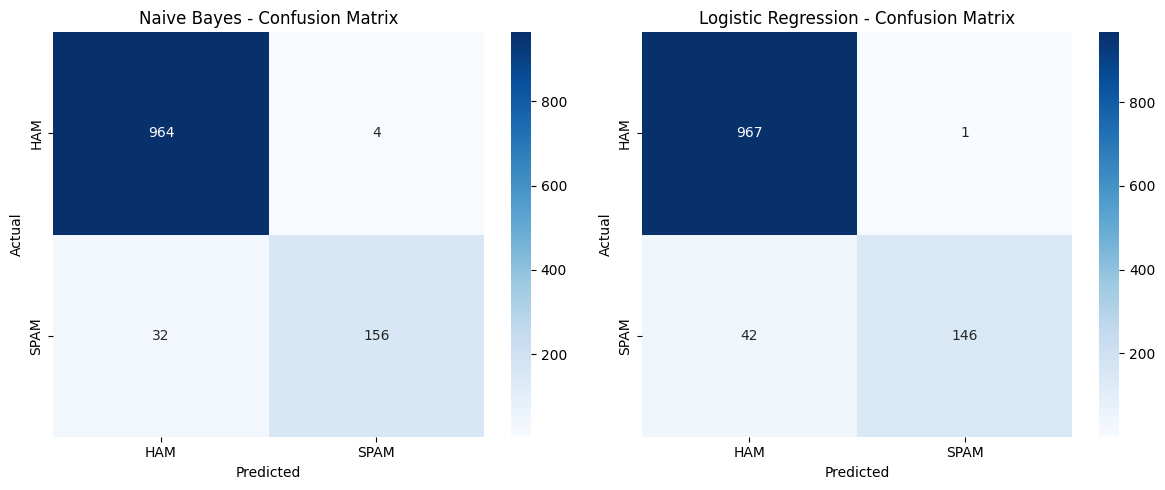

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['HAM', 'SPAM'], yticklabels=['HAM', 'SPAM'])
    axes[idx].set_title(f'{name} - Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

<H5>6.3 ROC CURVES</H3>

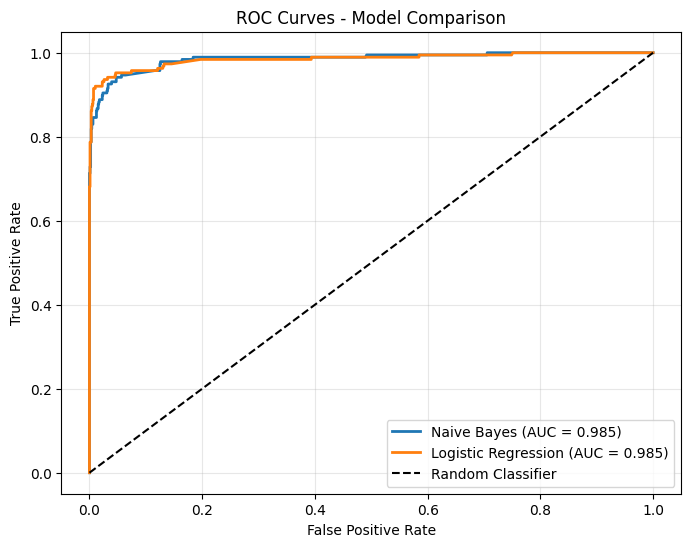

In [42]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<H5>6.4 Performance Metric Heatmap</H3>

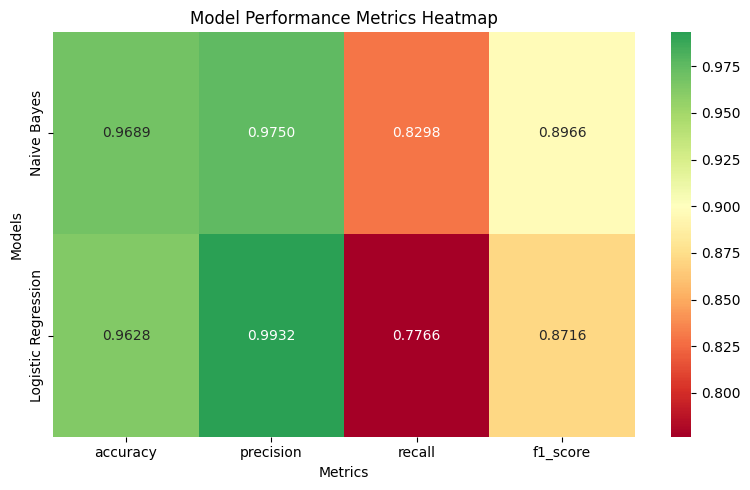

In [14]:
# Performance Metrics Heatmap

metrics_df = pd.DataFrame(results).T
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df, annot=True, fmt='.4f', cmap='RdYlGn', center=0.9)
plt.title('Model Performance Metrics Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Models')
plt.tight_layout()
plt.show()

<H5>6.4 Cross-Validation on Best Model</H3>


CROSS-VALIDATION (5-FOLD)

📊 Naive Bayes
----------------------------------------
Fold scores: ['0.9730', '0.9719', '0.9610', '0.9740', '0.9643']
Mean accuracy: 0.9688
Std deviation: 0.0052

📊 Logistic Regression
----------------------------------------
Fold scores: ['0.9611', '0.9567', '0.9524', '0.9589', '0.9437']
Mean accuracy: 0.9546
Std deviation: 0.0061

CROSS-VALIDATION CONCLUSION

✅ Best Model based on CV: Naive Bayes
   Mean CV Accuracy: 0.9688 (+/- 0.0052)


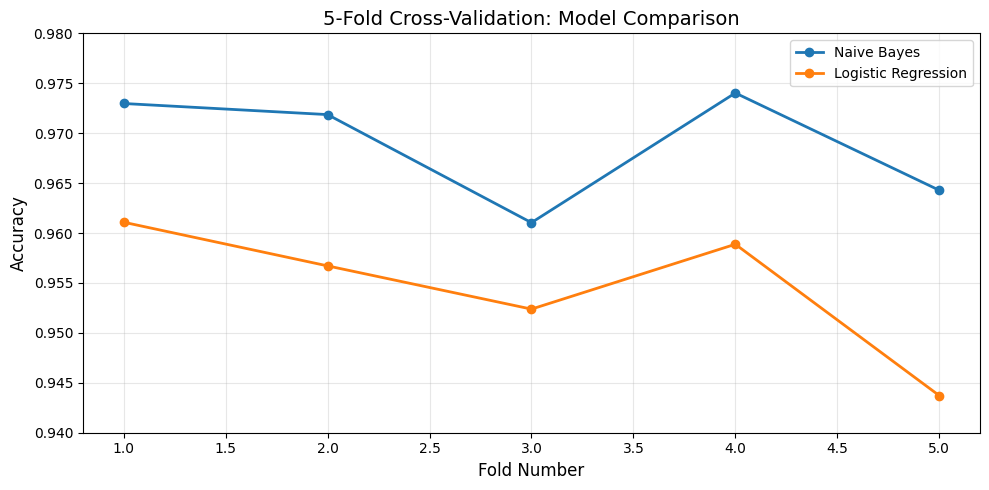


FINAL MODEL SELECTION
Selected Model: Naive Bayes
Selection Rationale: Higher cross-validation accuracy (0.9688)


In [44]:
# ===============================
# 6.1 CROSS-VALIDATION (MODEL COMPARISON)
# ===============================
print("\n" + "="*60)
print("CROSS-VALIDATION (5-FOLD)")
print("="*60)

# Define models to compare
models_to_cv = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

cv_results = {}
cv_scores_dict = {}

for name, model in models_to_cv.items():
    print(f"\n📊 {name}")
    print("-" * 40)
    
    # Perform 5-fold cross-validation on TRAINING data
    scores = cross_val_score(
        model,
        X_train_tfidf,
        y_train,
        cv=5,
        scoring='accuracy'
    )
    
    cv_scores_dict[name] = scores
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    
    print(f"Fold scores: {[f'{s:.4f}' for s in scores]}")
    print(f"Mean accuracy: {scores.mean():.4f}")
    print(f"Std deviation: {scores.std():.4f}")

# Determine best model based on CV results
best_cv_model = max(cv_results, key=lambda x: cv_results[x]['mean'])
best_cv_accuracy = cv_results[best_cv_model]['mean']

print("\n" + "="*60)
print("CROSS-VALIDATION CONCLUSION")
print("="*60)
print(f"\n✅ Best Model based on CV: {best_cv_model}")
print(f"   Mean CV Accuracy: {best_cv_accuracy:.4f} (+/- {cv_results[best_cv_model]['std']:.4f})")

# ===============================
# CROSS-VALIDATION VISUALIZATION
# ===============================

# Plot 1: Comparison of CV scores across folds
plt.figure(figsize=(10, 5))

for name, scores in cv_scores_dict.items():
    plt.plot(range(1, 6), scores, marker='o', label=name, linewidth=2)

plt.title('5-Fold Cross-Validation: Model Comparison', fontsize=14)
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.94, 0.98)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ===============================
# FINAL MODEL SELECTION
# ===============================
# Set the best model for final evaluation
best_model_name = best_cv_model
best_model = models_to_cv[best_cv_model]

print("\n" + "="*60)
print("FINAL MODEL SELECTION")
print("="*60)
print(f"Selected Model: {best_model_name}")
print(f"Selection Rationale: Higher cross-validation accuracy ({best_cv_accuracy:.4f})")

<H3>6.6 Feature Importance Top Words<H3>

<H5>6.6.1 Feature Importance Naive Bayes<H5>


TOP IMPORTANT FEATURES (WORDS)

Top SPAM words:
free
text
claim
txt
won
stop
mobile
reply
ur
prize

Top HAM words:
im
ok
ill
ltgt
just
come
dont
got
like
know


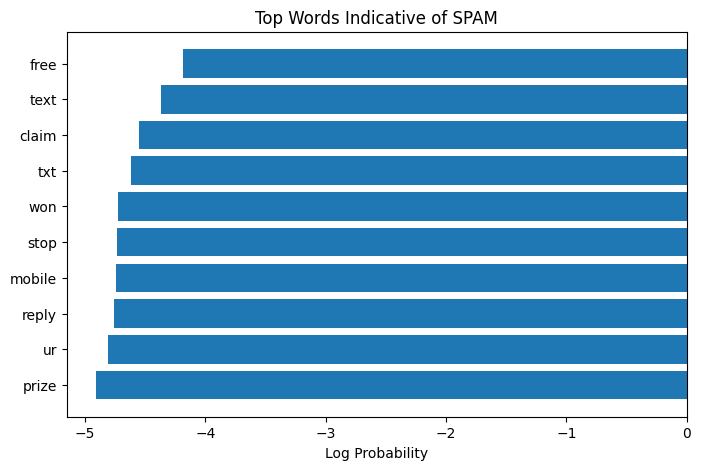

In [39]:
# ===============================
# FEATURE IMPORTANCE (TOP WORDS)
# ===============================
print("\n" + "="*60)
print("TOP IMPORTANT FEATURES (WORDS)")
print("="*60)

feature_names = tfidf.get_feature_names_out()
nb_model = models["Naive Bayes"]

# Get log probabilities
spam_probs = nb_model.feature_log_prob_[1]
ham_probs = nb_model.feature_log_prob_[0]

# Top spam words
top_spam_idx = spam_probs.argsort()[-10:]
top_ham_idx = ham_probs.argsort()[-10:]

print("\nTop SPAM words:")
for i in reversed(top_spam_idx):
    print(feature_names[i])

print("\nTop HAM words:")
for i in reversed(top_ham_idx):
    print(feature_names[i])


    # Plot top spam words
top_n = 10
indices = spam_probs.argsort()[-top_n:]

plt.figure(figsize=(8,5))
plt.barh(range(top_n), spam_probs[indices])
plt.yticks(range(top_n), [feature_names[i] for i in indices])
plt.title("Top Words Indicative of SPAM")
plt.xlabel("Log Probability")
plt.show()

<H5>6.6.2 Feature Importance Logistic Regression<H5>


FEATURE IMPORTANCE - LOGISTIC REGRESSION


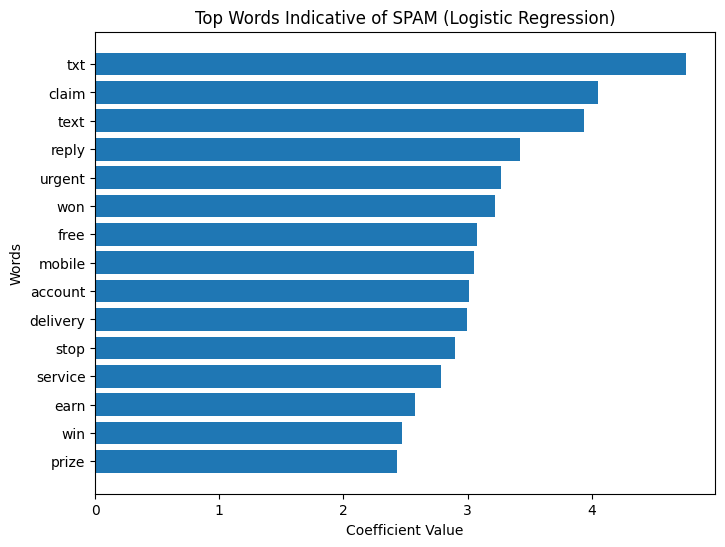

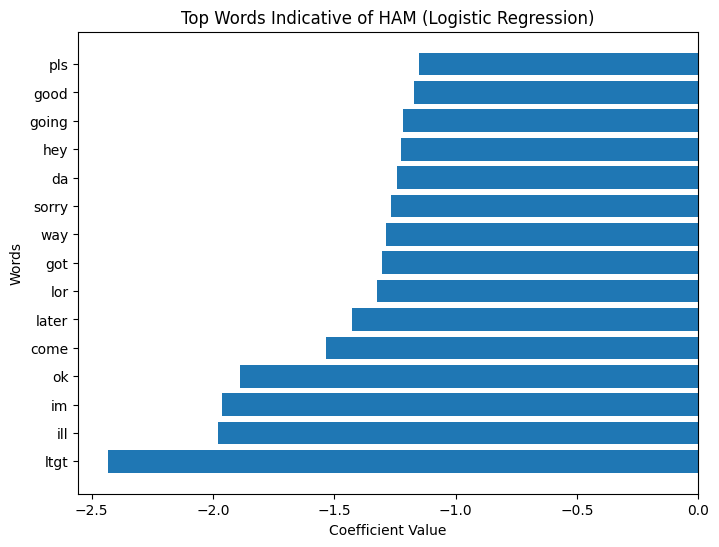

In [ ]:
# ===============================
# FEATURE IMPORTANCE (LOGISTIC REGRESSION)
# ===============================
lr_model = models["Logistic Regression"]
feature_names = tfidf.get_feature_names_out()

# Get coefficients
coefficients = lr_model.coef_[0]

# Top features
top_n = 15

# Top spam words (positive coefficients)
top_spam_idx = np.argsort(coefficients)[-top_n:]

# Top ham words (negative coefficients)
top_ham_idx = np.argsort(coefficients)[:top_n]

# Spam words plot
plt.figure(figsize=(8,6))
plt.barh(range(top_n), coefficients[top_spam_idx])
plt.yticks(range(top_n), [feature_names[i] for i in top_spam_idx])
plt.title("Top Words Indicative of SPAM (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Words")
plt.show()


# Ham Word plot
plt.figure(figsize=(8,6))
plt.barh(range(top_n), coefficients[top_ham_idx])
plt.yticks(range(top_n), [feature_names[i] for i in top_ham_idx])
plt.title("Top Words Indicative of HAM (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Words")
plt.show()



<H3>STEP 8: DETAILED CLASSIFICATION REPORT</H5>

In [34]:
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORTS")
print("="*60)

for name, model in models.items():
    print(f"\n📊 {name}")
    print("-"*40)
    y_pred = predictions[name]
    print(classification_report(y_test, y_pred, target_names=['HAM', 'SPAM']))



# ===============================
# MODEL COMPARISON SUMMARY TABLE
# ===============================
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame(results).T
print(comparison_df.round(4))

# Determine best model for each metric
print("\n" + "-"*40)
print("BEST MODEL PER METRIC:")
print("-"*40)
for metric in metrics:
    best = comparison_df[metric].idxmax()
    best_score = comparison_df[metric].max()
    print(f"{metric.capitalize():12} → {best:20} ({best_score:.4f})")


DETAILED CLASSIFICATION REPORTS

📊 Naive Bayes
----------------------------------------
              precision    recall  f1-score   support

         HAM       0.97      1.00      0.98       968
        SPAM       0.97      0.83      0.90       188

    accuracy                           0.97      1156
   macro avg       0.97      0.91      0.94      1156
weighted avg       0.97      0.97      0.97      1156


📊 Logistic Regression
----------------------------------------
              precision    recall  f1-score   support

         HAM       0.96      1.00      0.98       968
        SPAM       0.99      0.78      0.87       188

    accuracy                           0.96      1156
   macro avg       0.98      0.89      0.92      1156
weighted avg       0.96      0.96      0.96      1156


MODEL COMPARISON SUMMARY
                     accuracy  precision  recall  f1_score
Naive Bayes            0.9689     0.9750  0.8298    0.8966
Logistic Regression    0.9628     0.9932  0.7766 

<p>Summary of result</p>
<table border="1" cellpadding="10" cellspacing="0" style="border-collapse: collapse; width: 90%; margin: 20px 0; font-family: Arial, sans-serif;">
    <thead>
        <tr style="background-color: #3498db; color: white;">
            <th>Model</th>
            <th>Accuracy</th>
            <th>Precision</th>
            <th>Recall</th>
            <th>F1-Score</th>
            <th>Confusion Matrix</th>
        </tr>
    </thead>
    <tbody>
        <tr style="background-color: #5d5f5f;">
            <td style="font-weight: bold;">🏆 Naive Bayes</td>
            <td style="text-align: center; font-weight: bold;">96.89%</td>
            <td style="text-align: center;">97.50%</td>
            <td style="text-align: center; font-weight: bold;">82.98%</td>
            <td style="text-align: center; font-weight: bold;">89.66%</td>
            <td style="font-family: monospace;">[[964, 4]<br>[32, 156]]</td>
        </tr>
        <tr style="background-color: #7c7c7a;">
            <td>Logistic Regression</td>
            <td style="text-align: center;">96.28%</td>
            <td style="text-align: center; font-weight: bold;">99.32%</td>
            <td style="text-align: center;">77.66%</td>
            <td style="text-align: center;">87.16%</td>
            <td style="font-family: monospace;">[[967, 1]<br>[42, 146]]</td>
        </tr>
    </tbody>
</table>


<H3>STEP 9: Save Model For Deployment in Streamlit</H5>

In [ ]:
# Save your model and vectorizer 
joblib.dump(models['Naive Bayes'], 'spam_model.pkl')
joblib.dump(tfidf, 'vectorizer.pkl')

print("✅ Model saved as 'spam_model.pkl'")
print("✅ Vectorizer saved as 'vectorizer.pkl'")

✅ Model saved as 'spam_model.pkl'
✅ Vectorizer saved as 'vectorizer.pkl'
